In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Total columns: {len(df.columns)}")
print(f"📊 Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"📊 Cities: {df['City'].unique().tolist()}")
print(f"📊 Unique stations: {df['Station_id'].nunique()}")

✅ Data loaded successfully!
📊 Total rows: 661
📊 Total columns: 13
📊 Years: 2015 - 2024
📊 Cities: ['Cologne', 'Leipzig', 'Stuttgart']
📊 Unique stations: 469


In [ ]:
print("=" * 60)
print("📊 TEMPORAL HOLDOUT SPLIT")
print("=" * 60)

# Define train and test years
train_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023, 2024]

# Create train and test sets
train_df = df[df['Year'].isin(train_years)]
test_df = df[df['Year'].isin(test_years)]

print(f"\n📌 Training years: {train_years}")
print(f"   Rows in training: {len(train_df)}")
print(f"\n📌 Testing years: {test_years}")
print(f"   Rows in testing: {len(test_df)}")

print(f"\n📌 Train/Test split: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%")

# Show distribution by city
print("\n--- Training set by city ---")
print(train_df['City'].value_counts())

print("\n--- Testing set by city ---")
print(test_df['City'].value_counts())

# Save split information
with open('temporal_split_info.txt', 'w') as f:
    f.write("TEMPORAL HOLDOUT SPLIT\n")
    f.write("-" * 40 + "\n")
    f.write(f"Training years: {train_years}\n")
    f.write(f"Training rows: {len(train_df)}\n")
    f.write(f"Testing years: {test_years}\n")
    f.write(f"Testing rows: {len(test_df)}\n")
    f.write(f"Split ratio: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%\n")

print("\n✅ temporal_split_info.txt saved!")

📊 TEMPORAL HOLDOUT SPLIT

📌 Training years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
   Rows in training: 484

📌 Testing years: [2022, 2023, 2024]
   Rows in testing: 177

📌 Train/Test split: 73.2% / 26.8%

--- Training set by city ---
City
Leipzig      303
Stuttgart     96
Cologne       85
Name: count, dtype: int64

--- Testing set by city ---
City
Leipzig      75
Cologne      59
Stuttgart    43
Name: count, dtype: int64

✅ temporal_split_info.txt saved!


In [ ]:
print("=" * 60)
print("📊 LEAVE-ONE-STATION-OUT (LOSO) SPLIT")
print("=" * 60)

# Get all unique stations
all_stations = df['Station_id'].unique()
n_stations = len(all_stations)

print(f"\n📌 Total stations: {n_stations}")

# Show station count by city
station_counts = df.groupby('City')['Station_id'].nunique()
print("\n--- Stations by city ---")
print(station_counts)

# Create a summary of LOSO splits
station_summary = []

for station in all_stations[:10]:  # Show first 10 as example
    train_stations = [s for s in all_stations if s != station]
    station_data = df[df['Station_id'] == station]

    station_summary.append({
        'Station': station,
        'City': station_data['City'].iloc[0],
        'Rows_held_out': len(station_data),
        'Training_stations': len(train_stations)
    })

station_summary_df = pd.DataFrame(station_summary)
print("\n--- Example LOSO splits (first 10 stations) ---")
print(station_summary_df.to_string(index=False))

# Save full station list
station_list_df = pd.DataFrame({
    'Station_id': all_stations,
    'City': df.groupby('Station_id')['City'].first().values,
    'Total_Rows': df.groupby('Station_id').size().values
})
station_list_df = station_list_df.sort_values('City')
station_list_df.to_excel('station_list.xlsx', index=False)

print("\n✅ Full station list saved to: station_list.xlsx")
print(f"📌 Total stations: {n_stations}")

📊 LEAVE-ONE-STATION-OUT (LOSO) SPLIT

📌 Total stations: 469

--- Stations by city ---
City
Cologne       43
Leipzig      287
Stuttgart    139
Name: Station_id, dtype: int64

--- Example LOSO splits (first 10 stations) ---
 Station    City  Rows_held_out  Training_stations
10406426 Cologne             10                468
10201117 Cologne              3                468
10201531 Cologne              9                468
10203254 Cologne              8                468
10200691 Cologne              4                468
10200710 Cologne              5                468
10201026 Cologne              6                468
10201282 Cologne              6                468
10201312 Cologne              5                468
10202201 Cologne              3                468

✅ Full station list saved to: station_list.xlsx
📌 Total stations: 469


In [ ]:
print("=" * 60)
print("📊 ROLLING ORIGIN VALIDATION")
print("=" * 60)

# Get unique years
years = sorted(df['Year'].unique())
print(f"\n📌 Years available: {years}")

# Define rolling origins
rolling_origins = []

# Method: Start with 3 years, roll forward
for i in range(3, len(years)-1):
    train_years = years[:i]
    test_year = years[i]
    rolling_origins.append({
        'train_years': train_years,
        'test_year': test_year,
        'train_size': len(df[df['Year'].isin(train_years)]),
        'test_size': len(df[df['Year'] == test_year])
    })

print(f"\n📌 Number of rolling origins: {len(rolling_origins)}")
print("\n--- Rolling origins ---")
for ro in rolling_origins:
    print(f"  Train: {ro['train_years'][0]} - {ro['train_years'][-1]} ({ro['train_size']} rows) → Test: {ro['test_year']} ({ro['test_size']} rows)")

# Save rolling origin info
with open('rolling_origin_info.txt', 'w') as f:
    f.write("ROLLING ORIGIN VALIDATION\n")
    f.write("-" * 40 + "\n")
    for ro in rolling_origins:
        f.write(f"Train: {ro['train_years'][0]} - {ro['train_years'][-1]} ({ro['train_size']} rows) → Test: {ro['test_year']} ({ro['test_size']} rows)\n")

print("\n✅ rolling_origin_info.txt saved!")

📊 ROLLING ORIGIN VALIDATION

📌 Years available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

📌 Number of rolling origins: 6

--- Rolling origins ---
  Train: 2015 - 2017 (189 rows) → Test: 2018 (62 rows)
  Train: 2015 - 2018 (251 rows) → Test: 2019 (77 rows)
  Train: 2015 - 2019 (328 rows) → Test: 2020 (84 rows)
  Train: 2015 - 2020 (412 rows) → Test: 2021 (72 rows)
  Train: 2015 - 2021 (484 rows) → Test: 2022 (55 rows)
  Train: 2015 - 2022 (539 rows) → Test: 2023 (57 rows)

✅ rolling_origin_info.txt saved!


📊 VISUALIZING VALIDATION SPLITS


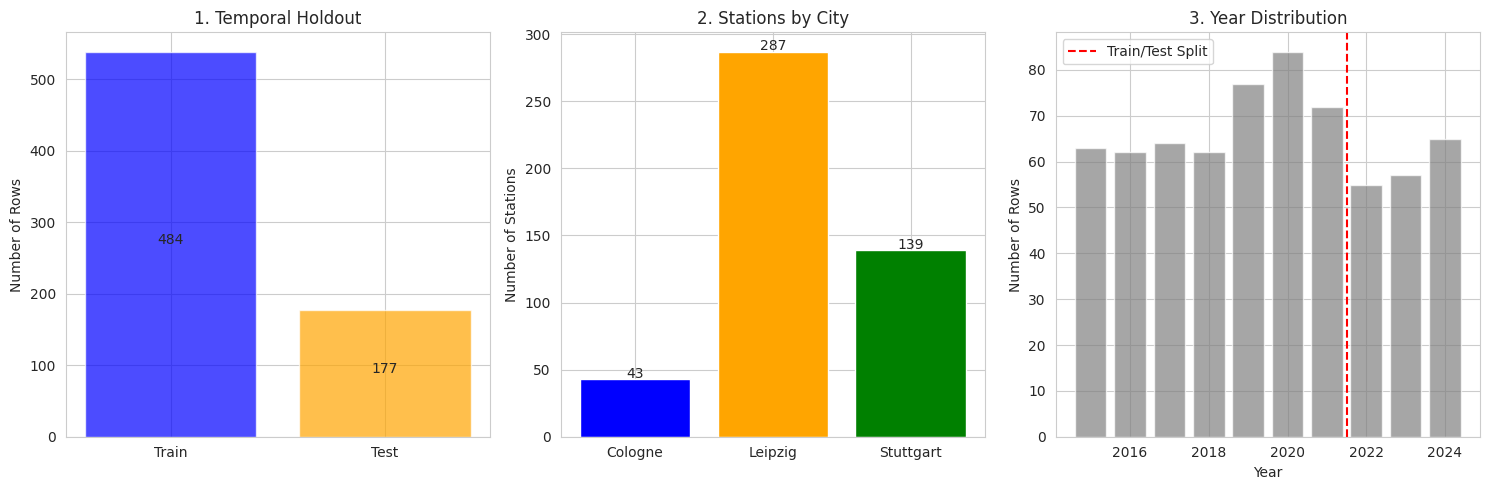

✅ validation_splits.png saved!


In [ ]:
print("=" * 60)
print("📊 VISUALIZING VALIDATION SPLITS")
print("=" * 60)

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Temporal Holdout
years_all = sorted(df['Year'].unique())
train_mask = df['Year'].isin(train_years)
test_mask = df['Year'].isin(test_years)

axes[0].bar('Train', len(df[train_mask]), color='blue', alpha=0.7)
axes[0].bar('Test', len(df[test_mask]), color='orange', alpha=0.7)
axes[0].set_title('1. Temporal Holdout')
axes[0].set_ylabel('Number of Rows')
axes[0].text(0, len(df[train_mask])/2, f'{len(train_df)}', ha='center')
axes[0].text(1, len(df[test_mask])/2, f'{len(test_df)}', ha='center')

# 2. Station Distribution
station_counts = df.groupby('City')['Station_id'].nunique()
axes[1].bar(station_counts.index, station_counts.values, color=['blue', 'orange', 'green'])
axes[1].set_title('2. Stations by City')
axes[1].set_ylabel('Number of Stations')
for i, v in enumerate(station_counts.values):
    axes[1].text(i, v+1, str(v), ha='center')

# 3. Year Distribution
year_counts = df['Year'].value_counts().sort_index()
axes[2].bar(year_counts.index, year_counts.values, color='gray', alpha=0.7)
axes[2].axvline(x=2021.5, color='red', linestyle='--', label='Train/Test Split')
axes[2].set_title('3. Year Distribution')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number of Rows')
axes[2].legend()

plt.tight_layout()
plt.savefig('validation_splits.png', dpi=300)
plt.show()
print("✅ validation_splits.png saved!")

In [ ]:
print("=" * 60)
print("📄 VALIDATION FRAMEWORK SUMMARY")
print("=" * 60)

with open('Validation_Framework_Summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("VALIDATION FRAMEWORK SUMMARY\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. DATASET SUMMARY\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total rows: {len(df)}\n")
    f.write(f"Total stations: {df['Station_id'].nunique()}\n")
    f.write(f"Years: {df['Year'].min()} - {df['Year'].max()}\n")
    f.write(f"Cities: {', '.join(df['City'].unique().tolist())}\n\n")

    f.write("2. TEMPORAL HOLDOUT SPLIT\n")
    f.write("-" * 40 + "\n")
    f.write(f"Training years: {train_years}\n")
    f.write(f"Training rows: {len(train_df)}\n")
    f.write(f"Testing years: {test_years}\n")
    f.write(f"Testing rows: {len(test_df)}\n")
    f.write(f"Split ratio: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%\n\n")

    f.write("3. LEAVE-ONE-STATION-OUT (LOSO)\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total stations: {n_stations}\n")
    f.write(f"Each iteration: Train on {n_stations-1} stations, Test on 1 station\n")
    f.write(f"Total LOSO iterations: {n_stations}\n\n")

    f.write("4. ROLLING ORIGIN\n")
    f.write("-" * 40 + "\n")
    f.write(f"Number of rolling origins: {len(rolling_origins)}\n")
    f.write("Each iteration: Train on 2015-X, Test on X+1\n\n")

    f.write("5. VALIDATION STRATEGY FOR MODELING\n")
    f.write("-" * 40 + "\n")
    f.write("Primary validation: Temporal holdout (2015-2021 train, 2022-2024 test)\n")
    f.write("Secondary validation: Leave-One-Station-Out (test generalization)\n")
    f.write("Tertiary validation: Rolling origin (test stability over time)\n\n")

    f.write("6. DATA LEAKAGE PREVENTION\n")
    f.write("-" * 40 + "\n")
    f.write("• All preprocessing fitted ONLY on training data\n")
    f.write("• Scaling: Fit on train, transform train and test\n")
    f.write("• Imputation: Fit on train, transform train and test\n")
    f.write("• Feature selection: Fit on train only\n")
    f.write("• Clustering: Fit on train only\n\n")

    f.write("7. METRICS TO REPORT\n")
    f.write("-" * 40 + "\n")
    f.write("• Primary: MAE (Mean Absolute Error)\n")
    f.write("• Secondary: RMSE (Root Mean Square Error)\n")
    f.write("• Supplementary: R²\n")
    f.write("• Uncertainty: Prediction interval coverage\n")
    f.write("• By group: Error by city, station, year, regime\n")

print("\n✅ Validation_Framework_Summary.txt saved!")

📄 VALIDATION FRAMEWORK SUMMARY

✅ Validation_Framework_Summary.txt saved!


In [ ]:
print("\n" + "=" * 60)
print("📁 FILES GENERATED")
print("=" * 60)

print("""
📄 Text Reports:
  ✅ temporal_split_info.txt
  ✅ rolling_origin_info.txt
  ✅ Validation_Framework_Summary.txt

📊 Excel Files:
  ✅ station_list.xlsx

📈 Plots (PNG):
  ✅ validation_splits.png

📌 All files are in your current directory.

PHASE 4 COMPLETE! ✅
Validation Framework is ready.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Validation_Framework_Summary.txt
  3. Tell me you're ready for Phase 5: Baseline Models
""")


📁 FILES GENERATED

📄 Text Reports:
  ✅ temporal_split_info.txt
  ✅ rolling_origin_info.txt
  ✅ Validation_Framework_Summary.txt

📊 Excel Files:
  ✅ station_list.xlsx

📈 Plots (PNG):
  ✅ validation_splits.png

📌 All files are in your current directory.

PHASE 4 COMPLETE! ✅
Validation Framework is ready.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Validation_Framework_Summary.txt
  3. Tell me you're ready for Phase 5: Baseline Models



In [ ]:
import os
import zipfile

with zipfile.ZipFile('Phase4_Validation_Files.zip', 'w') as zipf:
    for file in os.listdir():
        if file.endswith('.txt') or file.endswith('.xlsx') or file.endswith('.png'):
            if file not in ['Book1.xlsx']:
                zipf.write(file)

print("✅ Phase4_Validation_Files.zip created!")

✅ Phase4_Validation_Files.zip created!
